<a href="https://colab.research.google.com/github/suhaniahujaa/Neural-Network/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Q1. Explain the role of weights in a neuron?**

#####  In an artificial neural network, weights are the most critical parameters for learning. They function similarly to the strength of synaptic connections in a biological brain, determining how much influence an input has on the neuron's output. Each input (x) entering a neuron is multiplied by a specific weight (w). The neuron then sums these weighted inputs together.

Larger weights mean the input has more influence on the output. During training, weights are adjusted to minimize error and improve prediction accuracy.


## **Q2. What is an activation function?**
An activation function is a mathematical equation attached to each neuron in a neural network. Its primary role is to determine whether a neuron should "fire" (be activated) based on the weighted sum of its inputs.

Without an activation function, a neural network is just a giant linear regression model. No matter how many layers you add, the output would always be a simple linear transformation of the input.


## **Q3. Define Probability distribution in ML context?**
In the context of Machine Learning, a Probability Distribution is a mathematical function that describes the likelihood of obtaining the possible values that a random variable can take.

Essentially, it tells the model how data is spread out and which outcomes are "normal" versus "rare." It serves as the foundation for how machines handle uncertainty and make predictions.

## **Q4. What is gradient in optimization?**
The gradient is a vector of partial derivatives of the loss function with respect to model parameters. It indicates the direction of the steepest increase in error. In optimization, we move in the opposite direction of the gradient to minimize the loss. This process is used in Gradient Descent to train neural networks.

## **Project using logistic regression with tensor.**

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
score = tf.constant([20, 35,12, 65, 75, 90], dtype=tf.float32)
output = tf.constant([0, 0,0, 1, 1, 1], dtype=tf.float32)

In [3]:

m_eager = tf.Variable(0.0)
b_eager = tf.Variable(0.0)

learning_rate = 0.001
epochs = 100

for i in range(epochs):
  with tf.GradientTape() as tape:

    logits = m_eager * score + b_eager
    loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=output, logits=logits))

  grads = tape.gradient(loss, [m_eager, b_eager])
  m_eager.assign_sub(learning_rate * grads[0])
  b_eager.assign_sub(learning_rate * grads[1])

  if i % 20 == 0:
    print(f"[Eager] Step {i} : Loss ={loss.numpy():.4f}")

[Eager] Step 0 : Loss =0.6931
[Eager] Step 20 : Loss =0.5711
[Eager] Step 40 : Loss =0.5702
[Eager] Step 60 : Loss =0.5693
[Eager] Step 80 : Loss =0.5685


In [4]:
m_graph = tf.Variable(0.0)
b_graph = tf.Variable(0.0)

@tf.function
def train_step(x, y, m, b):
  with tf.GradientTape() as tape:
    logits = m * x + b
    y_pred = tf.nn.sigmoid(logits)
    loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y, y_pred))
  grads = tape.gradient(loss, [m, b])
  m.assign_sub(learning_rate * grads[0])
  b.assign_sub(learning_rate * grads[1])
  return loss

In [5]:
for i in range(epochs):
  loss=train_step(score,output,m_graph,b_graph)
  if i%20==0:
    print(f"[Graph] Step {i} : Loss ={loss.numpy():.4f}")

[Graph] Step 0 : Loss =0.6931
[Graph] Step 20 : Loss =0.5711
[Graph] Step 40 : Loss =0.5702
[Graph] Step 60 : Loss =0.5693
[Graph] Step 80 : Loss =0.5685


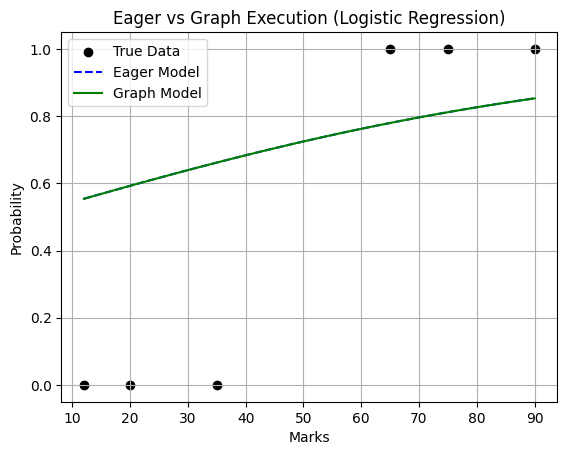

In [6]:
score_range = np.linspace(float(tf.reduce_min(score)), float(tf.reduce_max(score)), 100)

plt.scatter(score, output, label="True Data", color='black')

plt.plot(score_range, tf.nn.sigmoid(m_eager * score_range + b_eager), label="Eager Model", color="blue", linestyle="--")
plt.plot(score_range, tf.nn.sigmoid(m_graph * score_range + b_graph), label="Graph Model", color="green")

plt.xlabel("Marks")
plt.ylabel("Probability")
plt.title("Eager vs Graph Execution (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.show()